# Final Multimodal Fake News Detection Notebook

This notebook implements a full, end-to-end pipeline to train a multimodal (text + image) fake news detection model. It uses a self-contained, reliable dataset from Kaggle to ensure smooth execution.

**Pipeline Overview:**
1.  **Setup**: Mount Google Drive and create the project structure.
2.  **Data Acquisition (Kaggle)**: Download and prepare the dataset using the Kaggle API.
3.  **Feature Extraction**: Generate embeddings from text using **BERT** and from images using **ResNet50**.
4.  **Model Training & Evaluation**: Fuse features and train a neural network for classification.

---
## Part 1: Setup & Environment Configuration 🛠️
---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define the main project directory in your Google Drive
PROJECT_DIR = "/content/drive/MyDrive/final-multimodal-project"
!mkdir -p "{PROJECT_DIR}"
print("PROJECT_DIR:", PROJECT_DIR)

# Install all required libraries
!pip install -q pandas numpy scikit-learn tensorflow transformers torch pillow tqdm kaggle

import os
# Create the necessary subdirectories for our project
for d in ["data/raw", "data/processed", "models"]:
    os.makedirs(os.path.join(PROJECT_DIR, d), exist_ok=True)

print("\nProject directory structure created.")

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/final-multimodal-project

Project directory structure created.


---
## Part 2: Data Acquisition & Preparation (All-in-One) 📥
---

In [ ]:
import os
import pandas as pd
import requests

PROJECT_DIR = "/content/drive/MyDrive/final-multimodal-project"

# --- 1. Set up Kaggle API (Same as before) ---
if os.path.exists('kaggle.json'):
    print("✅ Kaggle API is already configured.")
else:
    try:
        from google.colab import files
        print("Please upload your kaggle.json file.")
        uploaded = files.upload()
        !mkdir -p ~/.kaggle
        !cp kaggle.json ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json
    except ImportError:
        print("❌ 'kaggle.json' not found. Please place it in your local directory.")

# --- 2. Download and Unzip the Dataset (Same as before) ---
data_dir = os.path.join(PROJECT_DIR, "data/raw")
inner_data_dir = os.path.join(data_dir, "multimodal_only_samples")
tsv_path = os.path.join(inner_data_dir, "multimodal_train.tsv")

if not os.path.exists(tsv_path):
    print(f"\\nDownloading dataset to {data_dir}...")
    !kaggle datasets download -d vanshikavmittal/fakeddit-dataset -p "{data_dir}" --unzip -q
else:
    print("\\nDataset manifest already downloaded.")

# --- 3. Load and Save the "To-Do List" ---
print(f"\\nLoading {tsv_path}...")
df_raw = pd.read_csv(tsv_path, sep='\\t', on_bad_lines='skip')
df = df_raw[['id', 'clean_title', 'image_url', '2_way_label']].copy()
df.dropna(subset=['image_url'], inplace=True)
df.rename(columns={'clean_title': 'text'}, inplace=True)

print(f"Loaded manifest with {len(df)} total samples.")

# --- FIX: Create the 'processed' directory before saving ---
processed_dir = os.path.join(PROJECT_DIR, "data/processed")
os.makedirs(processed_dir, exist_ok=True)
# --- END OF FIX ---

# Save this preliminary manifest
preliminary_csv_path = os.path.join(processed_dir, "1_preliminary_manifest.csv")
df.to_csv(preliminary_csv_path, index=False)
print(f"✅ Preliminary manifest saved to: {preliminary_csv_path}")

✅ Kaggle API is already configured.
\nDataset manifest already downloaded.
\nLoading /content/drive/MyDrive/final-multimodal-project/data/raw/multimodal_only_samples/multimodal_train.tsv...


/tmp/ipython-input-3476574730.py:34: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_raw = pd.read_csv(tsv_path, sep='\\t', on_bad_lines='skip')


Loaded manifest with 543465 total samples.
✅ Preliminary manifest saved to: /content/drive/MyDrive/final-multimodal-project/data/processed/1_preliminary_manifest.csv


In [ ]:
import os
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
from tqdm.notebook import tqdm

# Load the "to-do list"
preliminary_csv_path = os.path.join(PROJECT_DIR, "data/processed/1_preliminary_manifest.csv")
df = pd.read_csv(preliminary_csv_path)

df = df.head(108567)
print(f"Limiting download to {len(df)} images.")

images_folder_path = os.path.join(PROJECT_DIR, "data/raw", "images")
os.makedirs(images_folder_path, exist_ok=True)

print(f"\\nStarting resumable image download to: {images_folder_path}...")

# --- OPTIMIZATION ---
# 1. Get a list of all files ALREADY downloaded.
# This one call is slow, but much faster than 543,000 individual checks.
print("Scanning for already downloaded images. This might take a moment...")
try:
    already_downloaded = set(os.listdir(images_folder_path))
except Exception as e:
    print(f"Warning: Could not list directory, starting from scratch. Error: {e}")
    already_downloaded = set()
print(f"Found {len(already_downloaded)} images already on disk.")
# --- END OF OPTIMIZATION ---

print(f"This cell will check/download {len(df)} images.")
print("On reruns, this will be MUCH faster as it skips existing files.")

# We will use the 'id' to create the filename
for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Downloading Images"):
    try:
        image_id = row['id']
        url = row['image_url']
        filename = f"{image_id}.jpg" # The name of the file
        local_path = os.path.join(images_folder_path, filename) # The full path

        # --- KEY CHANGE: Check the set (in-memory, fast) not the disk (network, slow) ---
        if filename not in already_downloaded:
            # File is not in our set, so download it
            response = requests.get(url, timeout=10)
            response.raise_for_status()
            Image.open(BytesIO(response.content)).verify()
            with open(local_path, 'wb') as f:
                f.write(response.content)

            # Add the new file to the set so we don't re-download it
            # if the script restarts *during* this session.
            already_downloaded.add(filename)

    except Exception as e:
        # If one image fails, we just skip it and move to the next
        pass

print("\\n✅ Image download loop complete.")

Limiting download to 108567 images.
\nStarting resumable image download to: /content/drive/MyDrive/final-multimodal-project/data/raw/images...
Scanning for already downloaded images. This might take a moment...
Found 108571 images already on disk.
This cell will check/download 108567 images.
On reruns, this will be MUCH faster as it skips existing files.


\n✅ Image download loop complete.


In [ ]:
import os
import pandas as pd
from tqdm.notebook import tqdm

print("--- Creating Final Dataset Manifest ---")

preliminary_csv_path = os.path.join(PROJECT_DIR, "data/processed/1_preliminary_manifest.csv")
df = pd.read_csv(preliminary_csv_path)

# ⭐ Limit to the same number of images you downloaded
df = df.head(108567)
print(f"Limiting verification to {len(df)} rows.")

images_folder_path = os.path.join(PROJECT_DIR, "data/raw", "images")
final_csv_path = os.path.join(PROJECT_DIR, "data/processed/final_dataset.csv")

successful_rows = []
for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Verifying Images"):
    local_path = os.path.join(images_folder_path, f"{row['id']}.jpg")

    # Check if the image was successfully downloaded
    if os.path.exists(local_path):
        row['image_path'] = local_path
        successful_rows.append(row)

# Create the final, clean dataframe
df_final = pd.DataFrame(successful_rows)

# Save the final manifest
df_to_save = df_final[['text', 'image_path', '2_way_label']]
df_to_save.to_csv(final_csv_path, index=False)

print(f"\n✅ Final dataset manifest created with {len(df_to_save)} samples.")
print(f"Saved to: {final_csv_path}")

display(df_to_save.head())


--- Creating Final Dataset Manifest ---
Limiting verification to 108567 rows.


Verifying Images:   0%|          | 0/108567 [00:00<?, ?it/s]


✅ Final dataset manifest created with 71307 samples.
Saved to: /content/drive/MyDrive/final-multimodal-project/data/processed/final_dataset.csv


,text,image_path,2_way_label
0,my walgreens offbrand mucinex was engraved wit...,/content/drive/MyDrive/final-multimodal-projec...,1.0
2,hackers leak emails from uae ambassador to us,/content/drive/MyDrive/final-multimodal-projec...,1.0
4,bride and groom exchange vows after fatal shoo...,/content/drive/MyDrive/final-multimodal-projec...,1.0
5,major thermos,/content/drive/MyDrive/final-multimodal-projec...,0.0
6,rabbi meat from cloned pig could be kosher for...,/content/drive/MyDrive/final-multimodal-projec...,1.0


---
## Part 3: Feature Extraction (Embeddings) 🧠
---

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertModel
from tqdm.notebook import tqdm

# Load the final manifest
final_csv_path = os.path.join(PROJECT_DIR, "data/processed/final_dataset.csv")
df_final = pd.read_csv(final_csv_path)

# Load BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
bert.to(device)
print(f"Using device: {device} for BERT")

# Prepare texts for embedding
texts = df_final["text"].astype(str).tolist()
BATCH_SIZE = 32
MAX_LEN = 128

embs = []
bert.eval()
with torch.no_grad():
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Generating Text Embeddings"):
        batch = texts[i:i+BATCH_SIZE]
        toks = tokenizer(batch, truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors="pt")
        toks = {k: v.to(device) for k, v in toks.items()}
        out = bert(**toks)
        pool = out.last_hidden_state[:, 0, :].detach().cpu().numpy()
        embs.append(pool)

X_text = np.vstack(embs)
print("Final text embeddings shape:", X_text.shape)

# Save embeddings
text_emb_path = os.path.join(PROJECT_DIR, "data", "processed", "text_emb.npy")
np.save(text_emb_path, X_text)
print("Saved text embeddings to:", text_emb_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Using device: cuda for BERT


Generating Text Embeddings:   0%|          | 0/2229 [00:00<?, ?it/s]

Final text embeddings shape: (71307, 768)
Saved text embeddings to: /content/drive/MyDrive/final-multimodal-project/data/processed/text_emb.npy


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# =========================
# CONFIG
# =========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 256   # try 256; if you get OOM, drop to 128 or 64

drive_project_dir = PROJECT_DIR  # e.g. "/content/drive/MyDrive/final-multimodal-project"
drive_images_dir = os.path.join(drive_project_dir, "data", "raw", "images")
local_images_dir = "/content/images"  # fast local storage in Colab
final_csv_path = os.path.join(drive_project_dir, "data", "processed", "final_dataset.csv")
processed_dir = os.path.join(drive_project_dir, "data", "processed")
os.makedirs(processed_dir, exist_ok=True)

print("Available GPUs:", tf.config.list_physical_devices('GPU'))

# =========================
# 1. Load manifest
# =========================
df_final = pd.read_csv(final_csv_path).reset_index(drop=True)
print(f"Loaded final manifest with {len(df_final)} samples.")

# =========================
# 2. Ensure images are on local SSD
# =========================
if not os.path.exists(local_images_dir):
    print("Local images folder not found. Copying from Drive to local SSD (one-time)...")
    shutil.copytree(drive_images_dir, local_images_dir)
    print("Copy complete.")
else:
    print("Local images folder already exists. Skipping copy.")

# Update paths in df_final from Drive → local
df_final["image_path"] = df_final["image_path"].str.replace(
    drive_images_dir, local_images_dir, regex=False
)

img_paths = df_final["image_path"].tolist()
n_samples = len(img_paths)
print(f"Using {n_samples} local image paths.")

# =========================
# 3. Load fast backbone (MobileNetV2)
# =========================
base_model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
print("MobileNetV2 loaded.")

# =========================
# 4. tf.data pipeline (fast, batched, parallel)
# =========================
AUTOTUNE = tf.data.AUTOTUNE

def py_load_and_preprocess(path_str):
    """Python-side loader for robust error handling."""
    path_str = path_str.decode("utf-8")
    try:
        img = tf.keras.utils.load_img(path_str, target_size=IMG_SIZE)
        x = tf.keras.utils.img_to_array(img)
    except Exception as e:
        # Corrupt / unreadable image -> return black image
        # (We skip printing every warning to avoid slowing down.)
        x = np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype="float32")
    x = preprocess_input(x)
    return x.astype("float32")

def load_and_preprocess(path):
    img = tf.numpy_function(py_load_and_preprocess, [path], Tout=tf.float32)
    img.set_shape((*IMG_SIZE, 3))  # static shape needed for Keras
    return img

paths_ds = tf.data.Dataset.from_tensor_slices(img_paths)
ds = (
    paths_ds
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# =========================
# 5. Run batched inference
# =========================
print("Starting batched embedding extraction with MobileNetV2...")
X_img = base_model.predict(ds, verbose=1)
print("Image embeddings shape:", X_img.shape)  # (N, 1280)

# =========================
# 6. Save embeddings
# =========================
img_emb_path = os.path.join(processed_dir, "img_emb_mobilenet.npy")
np.save(img_emb_path, X_img)
print("Saved image embeddings to:", img_emb_path)


Available GPUs: []
Loaded final manifest with 71307 samples.
Local images folder already exists. Skipping copy.
Using 71307 local image paths.


/tmp/ipython-input-1449187399.py:52: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded.
Starting batched embedding extraction with MobileNetV2...
279/279 ━━━━━━━━━━━━━━━━━━━━ 3278s 12s/step
Image embeddings shape: (71307, 1280)
Saved image embeddings to: /content/drive/MyDrive/final-multimodal-project/data/processed/img_emb_mobilenet.npy


---
## Part 4: Model Training & Evaluation 🚀
---

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
import tensorflow as tf

# --- Load Data ---
X_text = np.load(os.path.join(PROJECT_DIR, "data", "processed", "text_emb.npy"))
X_img  = np.load(os.path.join(PROJECT_DIR, "data", "processed", "img_emb_mobilenet.npy"))
df_final = pd.read_csv(os.path.join(PROJECT_DIR, "data", "processed", "final_dataset.csv"))

print("Loaded shapes:")
print("X_text:", X_text.shape)
print("X_img:", X_img.shape)
print("df_final:", df_final.shape)

# --- Make sure lengths match (safety) ---
min_len = min(len(df_final), X_text.shape[0], X_img.shape[0])
df_final = df_final.iloc[:min_len].reset_index(drop=True)
X_text   = X_text[:min_len]
X_img    = X_img[:min_len]
print(f"\nAfter length alignment, samples: {min_len}")

# --- Clean data: drop rows with missing labels AND keep embeddings aligned ---
mask = df_final["2_way_label"].notna().values
before = len(df_final)
df_final = df_final[mask].reset_index(drop=True)
X_text   = X_text[mask]
X_img    = X_img[mask]
after = len(df_final)
print(f"Removed {before - after} rows with missing labels. Remaining samples: {after}")

# --- Create X and y from the clean and aligned data ---
y = df_final["2_way_label"].values.astype(int)
X = np.concatenate([X_text, X_img], axis=1)

print("Final X shape:", X.shape, "y shape:", y.shape)

# --- Train/val split ---
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")

# --- Class weights to handle imbalance ---
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)
class_weights = {cls: w for cls, w in zip(np.unique(y), class_weights_arr)}
print("Class weights:", class_weights)

# --- Define improved multimodal fusion model ---
inp = Input(shape=(X.shape[1],), name="fusion_input")

x = Dense(512, activation="relu", name="dense_512")(inp)
x = BatchNormalization(name="bn_1")(x)
x = Dropout(0.3, name="dropout_1")(x)

x = Dense(256, activation="relu", name="dense_256")(x)
x = BatchNormalization(name="bn_2")(x)
x = Dropout(0.3, name="dropout_2")(x)

x = Dense(128, activation="relu", name="dense_128")(x)
x = Dropout(0.3, name="dropout_3")(x)

out = Dense(1, activation="sigmoid", name="output")(x)

model = Model(inp, out, name="multimodal_fusion")

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

print("\nModel Summary:")
model.summary()

# --- Callbacks ---
model_dir = os.path.join(PROJECT_DIR, "models")
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "fusion_best_model.keras")  # modern format

chk = ModelCheckpoint(
    model_path,
    save_best_only=True,
    monitor="val_auc",      # focus on quality not just raw accuracy
    mode="max",
    verbose=1
)

es = EarlyStopping(
    patience=8,
    monitor="val_auc",
    mode="max",
    restore_best_weights=True,
    verbose=1
)

rlr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# --- Train ---
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=128,   # bump batch size a bit; lower to 64 if OOM
    callbacks=[chk, es, rlr],
    class_weight=class_weights,
    verbose=1
)

print("\nTraining finished. Best model saved to:", model_path)


Loaded shapes:
X_text: (71307, 768)
X_img: (71307, 1280)
df_final: (71307, 3)

After length alignment, samples: 71307
Removed 26 rows with missing labels. Remaining samples: 71281
Final X shape: (71281, 2048) y shape: (71281,)
Training samples: 57024, Validation samples: 14257
Class weights: {np.int64(0): np.float64(1.122853722314987), np.int64(1): np.float64(0.9013783510369247)}

Model Summary:


Model: "multimodal_fusion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fusion_input (InputLayer)       │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_512 (Dense)               │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,216,513 (4.64 MB)

 Trainable params: 1,214,977 (4.63 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/40
446/446 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.6783 - auc: 0.7392 - loss: 0.6421
Epoch 1: val_auc improved from -inf to 0.82761, saving model to /content/drive/MyDrive/final-multimodal-project/models/fusion_best_model.keras
446/446 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.6784 - auc: 0.7393 - loss: 0.6420 - val_accuracy: 0.7284 - val_auc: 0.8276 - val_loss: 0.5357 - learning_rate: 3.0000e-04
Epoch 2/40
444/446 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7452 - auc: 0.8224 - loss: 0.5255
Epoch 2: val_auc improved from 0.82761 to 0.85463, saving model to /content/drive/MyDrive/final-multimodal-project/models/fusion_best_model.keras
446/446 ━━━━━━━━━━━━━━━━━━━━ 35s 59ms/step - accuracy: 0.7453 - auc: 0.8224 - loss: 0.5255 - val_accuracy: 0.7673 - val_auc: 0.8546 - val_loss: 0.4866 - learning_rate: 3.0000e-04
Epoch 3/40
445/446 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7657 - auc: 0.8433 - loss: 0.4921
Epoch 3: val_auc improved from 0.85463 to 0.85918,

In [ ]:
df_final = pd.read_csv(os.path.join(PROJECT_DIR, "data", "processed", "final_dataset.csv"))
print(df_final['2_way_label'].value_counts())
print(df_final['2_way_label'].value_counts(normalize=True))


2_way_label
1.0    39540
0.0    31741
Name: count, dtype: int64
2_way_label
1.0    0.554706
0.0    0.445294
Name: proportion, dtype: float64


446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
--- Validation Set Performance ---
Accuracy: 0.8027

--- Classification Report ---
              precision    recall  f1-score   support

   Real News       0.77      0.79      0.78      6349
   Fake News       0.83      0.81      0.82      7908

    accuracy                           0.80     14257
   macro avg       0.80      0.80      0.80     14257
weighted avg       0.80      0.80      0.80     14257

ROC-AUC Score: 0.8875

--- Confusion Matrix ---


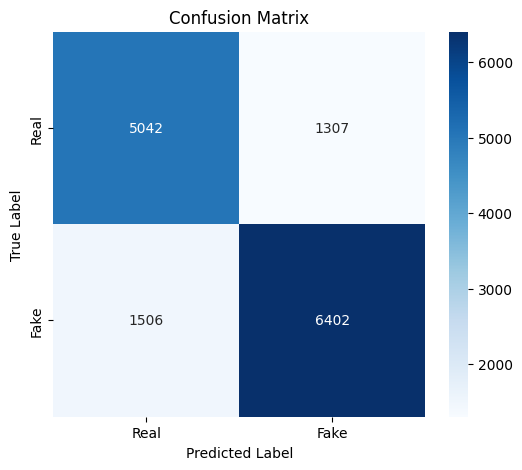

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load the best saved model for evaluation
model_path = os.path.join(PROJECT_DIR, "models", "fusion_best_model.keras")
best_model = load_model(model_path)

# Make predictions on the validation set
probs = best_model.predict(X_val).reshape(-1)
pred_val = (probs > 0.5).astype(int)

print(f"--- Validation Set Performance ---")
print(f"Accuracy: {accuracy_score(y_val, pred_val):.4f}")

# Print classification report
print("\n--- Classification Report ---")
print(classification_report(y_val, pred_val, target_names=['Real News', 'Fake News']))

# Print ROC-AUC score
try:
    auc = roc_auc_score(y_val, probs)
    print(f"ROC-AUC Score: {auc:.4f}")
except ValueError:
    print("ROC-AUC score could not be calculated (only one class present in predictions).")

# Plot confusion matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_val, pred_val)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

TEXT ONLY MODEL

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

# --- load aligned data like before (same as fusion setup) ---
X_text = np.load(os.path.join(PROJECT_DIR, "data", "processed", "text_emb.npy"))
X_img  = np.load(os.path.join(PROJECT_DIR, "data", "processed", "img_emb_mobilenet.npy"))
df_final = pd.read_csv(os.path.join(PROJECT_DIR, "data", "processed", "final_dataset.csv"))

min_len = min(len(df_final), X_text.shape[0], X_img.shape[0])
df_final = df_final.iloc[:min_len].reset_index(drop=True)
X_text   = X_text[:min_len]
X_img    = X_img[:min_len]

mask = df_final["2_way_label"].notna().values
df_final = df_final[mask].reset_index(drop=True)
X_text   = X_text[mask]
X_img    = X_img[mask]

y = df_final["2_way_label"].values.astype(int)

# SAME split as fusion so metrics compare nicely
X_text_train, X_text_val, y_train, y_val = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
X_img_train, X_img_val, _, _ = train_test_split(
    X_img, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
inp_t = Input(shape=(X_text.shape[1],))
x_t = Dense(256, activation="relu")(inp_t)
x_t = BatchNormalization()(x_t)
x_t = Dropout(0.3)(x_t)
x_t = Dense(128, activation="relu")(x_t)
x_t = Dropout(0.3)(x_t)
out_t = Dense(1, activation="sigmoid")(x_t)

text_model = Model(inp_t, out_t, name="text_only_model")
text_model.compile(
    optimizer=Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

es_t = EarlyStopping(patience=5, monitor="val_auc", mode="max", restore_best_weights=True, verbose=1)

history_t = text_model.fit(
    X_text_train, y_train,
    validation_data=(X_text_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[es_t],
    verbose=1
)

text_model.save(os.path.join(PROJECT_DIR, "models", "text_only_model.keras"))


Epoch 1/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.6756 - auc: 0.7367 - loss: 0.6239 - val_accuracy: 0.7648 - val_auc: 0.8443 - val_loss: 0.4849
Epoch 2/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.7557 - auc: 0.8311 - loss: 0.5043 - val_accuracy: 0.7754 - val_auc: 0.8561 - val_loss: 0.4703
Epoch 3/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.7680 - auc: 0.8448 - loss: 0.4846 - val_accuracy: 0.7832 - val_auc: 0.8636 - val_loss: 0.4592
Epoch 4/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.7808 - auc: 0.8580 - loss: 0.4657 - val_accuracy: 0.7880 - val_auc: 0.8690 - val_loss: 0.4494
Epoch 5/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7897 - auc: 0.8665 - loss: 0.4536 - val_accuracy: 0.7889 - val_auc: 0.8719 - val_loss: 0.4471
Epoch 6/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7984 - auc: 0.8756 - loss: 0.4381 - val_accuracy: 0.7889 - val_auc: 0.8747 - val_loss: 0.4484
Epoch 7/30
446/446 ━━━━━━━━━━━━

IMAGE ONLY **MODEL**

In [ ]:
import os
import numpy as np
import tensorflow as tf
import torch
from transformers import BertTokenizer, BertModel
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image

PROJECT_DIR = "/content/drive/MyDrive/final-multimodal-project"

# =========================
# 1. Load fusion model
# =========================
from tensorflow.keras.metrics import AUC

model_path = os.path.join(PROJECT_DIR, "models", "fusion_best_model.keras")
fusion_model = load_model(model_path, custom_objects={"AUC": AUC})
print("✅ Fusion model loaded successfully.")

# =========================
# 2. Load BERT (text encoder)
# =========================
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")

device = "cuda" if torch.cuda.is_available() else "cpu"
bert_model.to(device)
bert_model.eval()
print("✅ BERT model loaded successfully on", device)

# Text → 768-dim embedding
@torch.no_grad()
def encode_text(text: str, max_length: int = 128) -> np.ndarray:
    """
    Encode a single text string into a 768-dim BERT embedding.
    Uses [CLS] token representation.
    """
    encoded = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
    last_hidden = outputs.last_hidden_state  # (1, seq_len, 768)

    # Use [CLS] token (position 0) as sentence embedding
    cls_emb = last_hidden[:, 0, :]          # (1, 768)
    return cls_emb.squeeze(0).cpu().numpy().astype("float32")  # (768,)

# =========================
# 3. Load MobileNetV2 (image encoder)
# =========================
IMG_SIZE = (224, 224)

img_backbone = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
print("✅ MobileNetV2 image model loaded successfully.")

def encode_image(img_path: str) -> np.ndarray:
    """
    Encode an image file path into a 1280-dim MobileNetV2 embedding.
    """
    img = image.load_img(img_path, target_size=IMG_SIZE)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)  # MobileNetV2-specific pre-processing
    feats = img_backbone.predict(x, verbose=0)  # (1, 1280)
    return feats.squeeze(0).astype("float32")   # (1280,)

# =========================
# 4. Multimodal prediction helper
# =========================
def predict_news(text: str, img_path: str, threshold: float = 0.5):
    """
    Given raw text + image path, returns:
    - probability of 'Fake News' (class 1)
    - predicted label string
    """
    # 1) Encode text + image
    text_emb = encode_text(text)   # (768,)
    img_emb  = encode_image(img_path)  # (1280,)

    # 2) Concatenate to match fusion model input
    fused = np.concatenate([text_emb, img_emb], axis=0)  # (2048,)
    fused = np.expand_dims(fused, axis=0)  # (1, 2048)

    # 3) Predict with fusion model
    prob = fusion_model.predict(fused, verbose=0)[0, 0]  # scalar in [0,1]

    label = "Fake News" if prob >= threshold else "Real News"
    return float(prob), label

print("✅ Inference pipeline is ready.")

# =========================
# 5. Example usage
# =========================
example_text = "Government announces new policy on climate change."
example_image_path = "/content/images/some_example.jpg"  # change to a real path

# Uncomment after setting a valid path:
# prob, label = predict_news(example_text, example_image_path)
# print(f"Prediction: {label} (P(fake) = {prob:.4f})")


✅ Fusion model loaded successfully.
✅ BERT model loaded successfully on cpu


/tmp/ipython-input-942202716.py:62: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  img_backbone = MobileNetV2(


✅ MobileNetV2 image model loaded successfully.
✅ Inference pipeline is ready.


In [ ]:
def predict_fake_news(headline_text, image_path, threshold: float = 0.5):
    """
    Make a fake news prediction on a given headline + image path
    using the trained fusion model.

    Args:
        headline_text (str): The news headline text.
        image_path (str): The local file path to the image.
        threshold (float): Decision threshold on P(fake). Default = 0.5.

    Returns:
        dict: {
            "prediction": "Fake News" or "Real News",
            "prob_fake": float in [0,1],
            "confidence_score": "xx.xx%",   # formatted for the predicted class
        }
        or an error dict if image cannot be processed.
    """
    # ---------- 1. TEXT EMBEDDING (BERT) ----------
    try:
        with torch.no_grad():
            toks = tokenizer(
                headline_text,
                truncation=True,
                padding="max_length",
                max_length=128,
                return_tensors="pt"
            )
            toks = {k: v.to(device) for k, v in toks.items()}
            out = bert_model(**toks)
            # CLS token embedding -> shape (1, 768)
            text_emb = out.last_hidden_state[:, 0, :].detach().cpu().numpy().astype("float32")
    except Exception as e:
        return {"error": f"Could not process text: {e}"}

    # ---------- 2. IMAGE EMBEDDING (MobileNetV2) ----------
    try:
        img = image.load_img(image_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)  # MobileNetV2 preprocessing
        image_emb = img_backbone.predict(x, verbose=0).astype("float32")  # shape (1, 1280)
    except Exception as e:
        return {"error": f"Could not process image: {e}"}

    # ---------- 3. COMBINE EMBEDDINGS & PREDICT ----------
    # Both are already 2D: (1, 768) and (1, 1280)
    combined_emb = np.concatenate([text_emb, image_emb], axis=1)  # (1, 2048)

    # Get probability P(fake)
    prob_fake = float(fusion_model.predict(combined_emb, verbose=0)[0, 0])

    # ---------- 4. FORMAT OUTPUT ----------
    if prob_fake >= threshold:
        prediction = "Fake News"
        confidence = prob_fake
    else:
        prediction = "Real News"
        confidence = 1.0 - prob_fake

    result = {
        "prediction": prediction,
        "prob_fake": prob_fake,
        "confidence_score": f"{confidence:.2%}",
    }
    return result

print("✅ Prediction function 'predict_fake_news' is ready to use (MobileNetV2 + BERT + fusion model).")


✅ Prediction function 'predict_fake_news' is ready to use (MobileNetV2 + BERT + fusion model).


--- Sample for Prediction ---
Text: rare photo of north korea nuking the winter olympics in pyeongchang live
Image path: /content/drive/MyDrive/final-multimodal-project/data/raw/images/7yv5x3.jpg
Actual Label: Real News


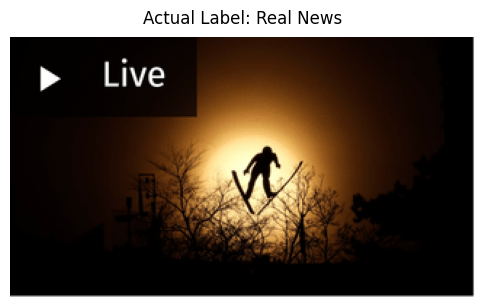


--- Model's Prediction ---
Prediction: Real News
Confidence: 100.00%
------------------------


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# --- 1. Load dataset manifest ---
final_csv_path = os.path.join(PROJECT_DIR, "data", "processed", "final_dataset.csv")
df_final = pd.read_csv(final_csv_path)

# Option A: fixed sample
# sample_row = df_final.iloc[2]

# Option B: random sample (recommended)
sample_row = df_final.sample(1, random_state=42).iloc[0]

sample_text = sample_row["text"]
sample_image_path = sample_row["image_path"]

label_value = sample_row["2_way_label"]
actual_label = "Fake News" if int(label_value) == 1 else "Real News"

print("--- Sample for Prediction ---")
print("Text:", sample_text)
print("Image path:", sample_image_path)
print("Actual Label:", actual_label)

# --- 2. Visualize the sample ---
try:
    img = mpimg.imread(sample_image_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    # Use '\n' for line breaks; no 'wrap' kwarg in plt.title
    plt.title(f"Actual Label: {actual_label}", pad=10)
    plt.axis("off")
    plt.show()

except Exception as e:
    print(f"Could not display image. Error: {e}")

# --- 3. Make the prediction ---
prediction_result = predict_fake_news(sample_text, sample_image_path)

print("\n--- Model's Prediction ---")
if "error" in prediction_result:
    print("Error:", prediction_result["error"])
else:
    print(f"Prediction: {prediction_result.get('prediction')}")
    print(f"Confidence: {prediction_result.get('confidence_score')}")
print("------------------------")


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q datasets pillow

**IMAGE ONLY MODEL**

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from datasets import load_dataset

# =========================
# CONFIG
# =========================
N_SAMPLES = 1000       # only use 1000 samples
BATCH_SIZE = 32
NUM_EPOCHS = 20
LR = 1e-3
IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# =========================
# 1. Load dataset and take 1000 samples
#    (avoid split slicing to fix NonMatchingSplitsSizesError)
# =========================
hf_ds_full = load_dataset(
    "Parveshiiii/AI-vs-Real",
    split="train",
    verification_mode="no_checks",  # ✅ Skip broken split-size check
)

print("Full train split size:", len(hf_ds_full))  # should be 13999 now

# Shuffle and pick first N_SAMPLES
hf_ds = hf_ds_full.shuffle(seed=42).select(range(N_SAMPLES))

print("Using", len(hf_ds), "samples for training/validation")

# =========================
# 2. Torch Dataset wrapper
# =========================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

class AIVsRealDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]
        img = sample["image"]                  # PIL image
        label = int(sample["binary_label"])    # 0 or 1

        if self.transform is not None:
            img = self.transform(img)

        return img, label

full_dataset = AIVsRealDataset(hf_ds, transform=transform)

# =========================
# 3. Train/Val split (800 / 200)
# =========================
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train size: {len(train_ds)}, Val size: {len(val_ds)}")

# =========================
# 4. Simple CNN model
# =========================
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112x112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56x56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)  # binary output (logit)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# =========================
# 5. Training & eval loops
# =========================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)  # (B, 1)

        optimizer.zero_grad()
        outputs = model(imgs)  # logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        preds = (torch.sigmoid(outputs) > 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += imgs.size(0)

    return running_loss / total, correct / total


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)

            preds = (torch.sigmoid(outputs) > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += imgs.size(0)

    return running_loss / total, correct / total

best_val_acc = 0.0
best_model_path = "/content/drive/MyDrive/final-multimodal-project/models/image_auth_model_torch.pth"

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, DEVICE)

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print("✅ Best model saved")

print("Training finished. Best Val Acc:", best_val_acc)



Using device: cuda
Full train split size: 13999
Using 1000 samples for training/validation
Train size: 800, Val size: 200
Epoch 1/20 | Train Loss: 0.6582, Train Acc: 0.7050 | Val Loss: 0.5506, Val Acc: 0.7200
✅ Best model saved
Epoch 2/20 | Train Loss: 0.5087, Train Acc: 0.7762 | Val Loss: 0.4484, Val Acc: 0.8400
✅ Best model saved
Epoch 3/20 | Train Loss: 0.4180, Train Acc: 0.8237 | Val Loss: 0.3999, Val Acc: 0.8350
Epoch 4/20 | Train Loss: 0.3973, Train Acc: 0.8350 | Val Loss: 0.3607, Val Acc: 0.8300
Epoch 5/20 | Train Loss: 0.3770, Train Acc: 0.8575 | Val Loss: 0.3605, Val Acc: 0.8400
Epoch 6/20 | Train Loss: 0.3771, Train Acc: 0.8562 | Val Loss: 0.4031, Val Acc: 0.8200
Epoch 7/20 | Train Loss: 0.3467, Train Acc: 0.8750 | Val Loss: 0.3056, Val Acc: 0.8650
✅ Best model saved
Epoch 8/20 | Train Loss: 0.2929, Train Acc: 0.8862 | Val Loss: 0.3139, Val Acc: 0.8750
✅ Best model saved
Epoch 9/20 | Train Loss: 0.2485, Train Acc: 0.8988 | Val Loss: 0.2614, Val Acc: 0.9000
✅ Best model saved


In [19]:
import os

BASE_DIR = "/content/drive/MyDrive/final-multimodal-project/data/image_auth"
AI_DIR = os.path.join(BASE_DIR, "ai")
REAL_DIR = os.path.join(BASE_DIR, "authentic")

os.makedirs(AI_DIR, exist_ok=True)
os.makedirs(REAL_DIR, exist_ok=True)

print("Folders ready.")


Folders ready.


In [20]:
from datasets import load_dataset

dataset = load_dataset(
    "Parveshiiii/AI-vs-Real",
    split="train",
    streaming=True   # ✅ avoids big downloads
)

print("Dataset streaming started.")


Dataset streaming started.


In [21]:
from PIL import Image
from tqdm import tqdm

MAX_PER_CLASS = 2000
ai_count = 0
real_count = 0

for sample in tqdm(dataset, total=4000):
    img = sample["image"]          # PIL image
    label = sample["binary_label"] # 1 = AI, 0 = Real

    if label == 1 and ai_count < MAX_PER_CLASS:
        img.save(os.path.join(AI_DIR, f"ai_{ai_count}.jpg"))
        ai_count += 1

    elif label == 0 and real_count < MAX_PER_CLASS:
        img.save(os.path.join(REAL_DIR, f"real_{real_count}.jpg"))
        real_count += 1

    if ai_count >= MAX_PER_CLASS and real_count >= MAX_PER_CLASS:
        break

print("Downloaded:")
print("AI images:", ai_count)
print("Real images:", real_count)


5999it [01:04, 93.20it/s]

Downloaded:
AI images: 2000
Real images: 2000


In [22]:
print("AI images:", len(os.listdir(AI_DIR)))
print("Authentic images:", len(os.listdir(REAL_DIR)))


AI images: 2000
Authentic images: 2000
